# Nigerian Ministry of Education - Student Performance Analysis

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Load and Inspect the Data

In [35]:
df = pd.read_csv("../data/students.csv")

print("Dataset shape:", df.shape)
print("\nFirst 3 rows:")
print(df.head(3))
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (2400, 38)

First 3 rows:
        student_id first_name middle_name last_name gender date_of_birth  \
0  ALA-20240729001     Obinna         NaN    Okafor      M    2010-06-15   
1  ALA-20240712002    Kelechi       Bello      Musa      M    2008-01-20   
2  ALA-20240809003   Temitope         NaN     Nwosu      M    2010-02-22   

  admission_date  class_level study_group  attendance  ...  Chemistry  \
0     2024-07-29           10     Science        90.1  ...      100.0   
1     2024-07-12           10        Arts        92.1  ...        NaN   
2     2024-08-09           10     Science        91.1  ...       21.0   

   Further Mathematics Civic Education Computer Science Hausa  \
0                 79.0             NaN             11.0   NaN   
1                  NaN           100.0              NaN  58.0   
2                100.0             NaN             34.0   NaN   

   English Language Government Mathematics Yoruba Literature in English  
0               100       

### Step 2: Data Cleaning and Preparation

In [36]:
class_level_map = {
    10: "SS1",
    11: "SS2",
    12: "SS3"
}

df["class_level"] = df["class_level"].replace(class_level_map)

df.rename(
    columns={
        "Further Mathematics": "further_mathematics",
        "Civic Education": "civic_education",
        "Computer Science": "computer_science",
        "English Language": "english_language",
        "Literature in English": "literature_in_english",
        "Mathematics": "mathematics",
        "Biology": "biology",
        "Physics": "physics",
    },
    inplace=True,
)

# Define a preferred order for income levels (low -> high)
income_order = ["Low", "Lower Middle", "Upper Middle", "High"]

# Convert data in family_income_level column to an order Categorical so plots sort correctly
df["family_income_level"] = pd.Categorical(df["family_income_level"], categories=income_order, ordered=True)

# Define the correct order for study hours (low -> high)
study_hours_order = ["0-1 Hour", "1-2 Hours", "2-3 Hours", "More than 3 hours"]

df["daily_study_hours"] = pd.Categorical(df["daily_study_hours"], categories=study_hours_order, ordered=True)

# print("\nIncome level value counts:")
# print(df["family_income_level"].value_counts())
#
# print("")
#
# print("\nDaily study hours value counts:")
# print(df["daily_study_hours"].value_counts())

### Task 1: Violin Plots

Mathematics and English Language scores by family income level

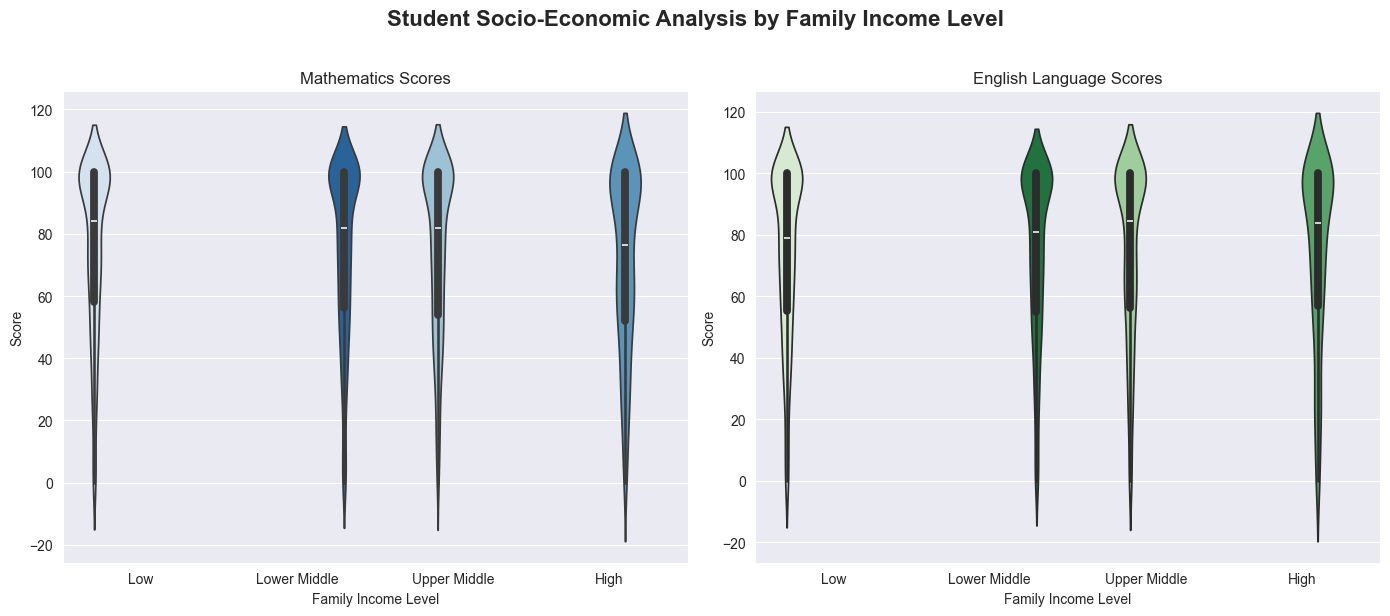

In [37]:
# Drop rows where Maths or English score is missing
violin_df = df.dropna(subset=["mathematics", "english_language"])

# Create a figure with two (2) subplots (violin plots, side-by-sde)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
fig.suptitle("Student Socio-Economic Analysis by Family Income Level", fontsize=16, fontweight="bold", y=1.02)

# Left plot: Mathematics
sns.violinplot(
    data=violin_df,
    x="family_income_level",
    y="mathematics",
    ax=axes[0],
    hue="family_income_level",
    order=income_order,
    legend=False,
    palette="Blues",
    inner="box",
)

axes[0].set_title("Mathematics Scores")
axes[0].set_xlabel("Family Income Level")
axes[0].set_ylabel("Score")
# axes[0].tick_params(axis="x", rotation=15)


# Right plot: English Language
sns.violinplot(
    data=violin_df,
    x="family_income_level",
    y="english_language",
    ax=axes[1],
    hue="family_income_level",
    order=income_order,
    legend=False,
    palette="Greens",
    inner="box",
)

axes[1].set_title("English Language Scores")
axes[1].set_xlabel("Family Income Level")
axes[1].set_ylabel("Score")
# axes[0].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("students_socioeconomic_analysis_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

### Task 2: Pair Plot

Relationships between core subject scores colored by gender

    mathematics  english_language  biology  physics  gender
0             0               100     52.0     35.0    Male
2            57                 0    100.0    100.0    Male
4           100                56     44.0     83.0  Female
9           100                17    100.0    100.0    Male
12          100                17     41.0     19.0    Male


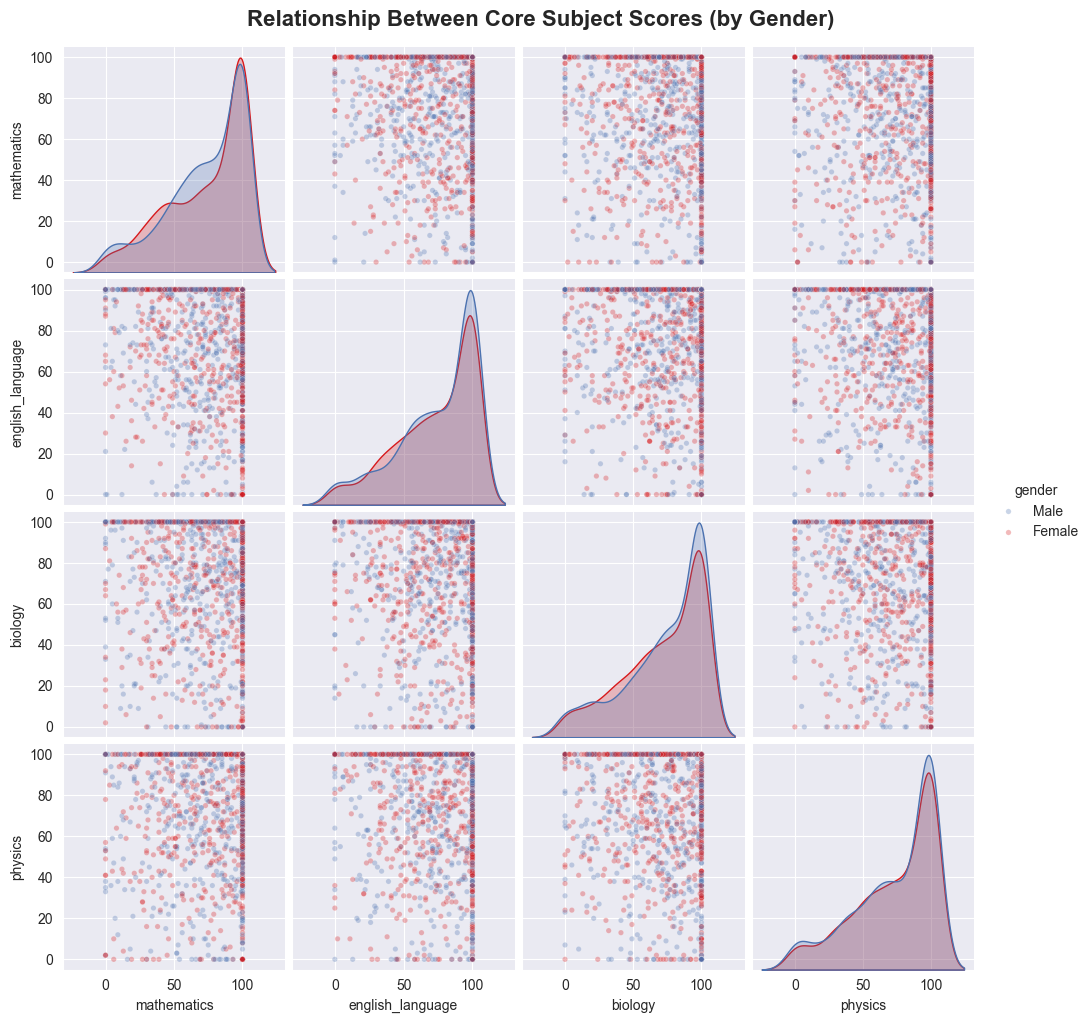

In [38]:
core_subjects = ["mathematics", "english_language", "biology", "physics"]
all_columns = core_subjects + ["gender"]

pair_df = df.dropna(subset=all_columns)

# Map gender codes to readable labels
pair_df = pair_df.copy()
pair_df["gender"] = pair_df["gender"].map({
    "M": "Male",
    "F": "Female",
})

# Build the pair plot
pair_plot = sns.pairplot(
    pair_df[all_columns],
    hue="gender",
    palette={ "Male": "#4c72b0", "Female": "#d7191c" },
    plot_kws={"alpha": 0.3, "s": 15},
    diag_kind="kde",
)

pair_plot.fig.suptitle("Relationship Between Core Subject Scores (by Gender)", fontsize=16, fontweight="bold", y=1.02)
pair_plot.savefig("pairplot.png", dpi=300, bbox_inches="tight")
plt.show()